# Задача 5. Обучение без учителя

* **Дедлайн**: 14.03.2025, 23:59
* **Основной полный балл**: 5
* **Максимум баллов**: 10

## Задача

- [x] Найти данные с количеством признаков хотя бы 50, на которых можно решить задачу кластеризации.
- [x] Выполнить разведочный анализ (**EDA**). При необходимости выполнить полезные преобразования данных.
- [x] Самостоятельно реализуйте один из алгоритмов кластеризации, например **K-means**.
- [x] Обучите модели кластеризации, используя свою реализацию, а также хотя бы две реализации из **sklearn** (**KMeans**, **Affinity Propogation**, **DBSCAN** и тд).
- [x] При обучении использовать **подбор гиперпараметров**.
- [x] Сравнить качество моделей: замерить скорость обучения, вычислить различные метрики качества.
- [x] * (**+3 балла**) Также снизить размерность данных с помощью метода главных компонент **PCA** и и понять качество дальнейшей кластеризации всеми использованными реализациями при различном количестве главных компонент.
- [x] * (**+2 балла**) Визуализировать данные снижением размерности до 2 или 3 с помощью **PCA** и **t-SNE**. В случае проблем с производительностью **t-SNE**, можно сначала до какой то степени снизить размерность с помощью **PCA**, а затем запустить **t-SNE**.


### Найти данные с количеством признаков хотя бы 50, на которых можно решить задачу кластеризации.

In [1150]:
import kagglehub
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import numpy as np
import time
from sklearn.metrics import (
    davies_bouldin_score,
    silhouette_score,
)

rng = 52

sns.set_theme(style="whitegrid")
np.random.seed(rng)

In [1151]:

path = kagglehub.dataset_download("mboaglio/simplifiedhuarus")

df = pd.read_csv(path + "/train.csv")

print("Количество строк и столбцов: ", df.shape)

Количество строк и столбцов:  (3609, 563)


### Выполнить разведочный анализ (**EDA**). При необходимости выполнить полезные преобразования данных.

In [1152]:
df.head()

,rn,activity,tBodyAcc.mean.X,tBodyAcc.mean.Y,tBodyAcc.mean.Z,tBodyAcc.std.X,tBodyAcc.std.Y,tBodyAcc.std.Z,tBodyAcc.mad.X,tBodyAcc.mad.Y,...,fBodyBodyGyroJerkMag.meanFreq,fBodyBodyGyroJerkMag.skewness,fBodyBodyGyroJerkMag.kurtosis,angle.tBodyAccMean.gravity,angle.tBodyAccJerkMean.gravityMean,angle.tBodyGyroMean.gravityMean,angle.tBodyGyroJerkMean.gravityMean,angle.X.gravityMean,angle.Y.gravityMean,angle.Z.gravityMean
0,7,STANDING,0.279,-0.0196,-0.1100,-0.997,-0.967,-0.983,-0.997,-0.966,...,0.146,-0.217,-0.5640,-0.2130,-0.2310,0.0146,-0.190,-0.852,0.182,-0.0430
1,11,STANDING,0.277,-0.0127,-0.1030,-0.995,-0.973,-0.985,-0.996,-0.974,...,0.121,0.349,0.0577,0.0807,0.5960,-0.4760,0.116,-0.852,0.188,-0.0347
2,14,STANDING,0.277,-0.0147,-0.1070,-0.999,-0.991,-0.993,-0.999,-0.991,...,0.740,-0.564,-0.7660,0.1060,-0.0903,-0.1320,0.499,-0.850,0.189,-0.0351
3,15,STANDING,0.298,0.0271,-0.0617,-0.989,-0.817,-0.902,-0.989,-0.794,...,0.131,0.208,-0.0681,0.0623,-0.0587,0.0312,-0.269,-0.731,0.283,0.0364
4,20,STANDING,0.276,-0.0170,-0.1110,-0.998,-0.991,-0.998,-0.998,-0.989,...,0.667,-0.942,-0.9660,0.2450,0.1030,0.0661,-0.412,-0.761,0.263,0.0296


In [1153]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3609 entries, 0 to 3608
Columns: 563 entries, rn to angle.Z.gravityMean
dtypes: float64(561), int64(1), str(1)
memory usage: 15.5 MB


In [1154]:
print("Пропущенных значений: ", df.isnull().sum().sum())

Пропущенных значений:  0


In [1155]:
print("Дубликатов: ", df.duplicated().sum())

Дубликатов:  0


In [1156]:
df.columns


Index(['rn', 'activity', 'tBodyAcc.mean.X', 'tBodyAcc.mean.Y',
       'tBodyAcc.mean.Z', 'tBodyAcc.std.X', 'tBodyAcc.std.Y', 'tBodyAcc.std.Z',
       'tBodyAcc.mad.X', 'tBodyAcc.mad.Y',
       ...
       'fBodyBodyGyroJerkMag.meanFreq', 'fBodyBodyGyroJerkMag.skewness',
       'fBodyBodyGyroJerkMag.kurtosis', 'angle.tBodyAccMean.gravity',
       'angle.tBodyAccJerkMean.gravityMean', 'angle.tBodyGyroMean.gravityMean',
       'angle.tBodyGyroJerkMean.gravityMean', 'angle.X.gravityMean',
       'angle.Y.gravityMean', 'angle.Z.gravityMean'],
      dtype='str', length=563)

In [1157]:
labels = df["activity"]
X_raw = df.drop(["rn", "activity"], axis=1)

# Числовые метки классов (порядок как в pd.factorize — по первому появлению в столбце)
Y, uniques = pd.factorize(labels)
labels_keys = uniques.tolist()

print("Активности:", labels_keys)

Активности: ['STANDING', 'SITTING', 'LAYING', 'WALKING', 'WALKING_DOWNSTAIRS', 'WALKING_UPSTAIRS']


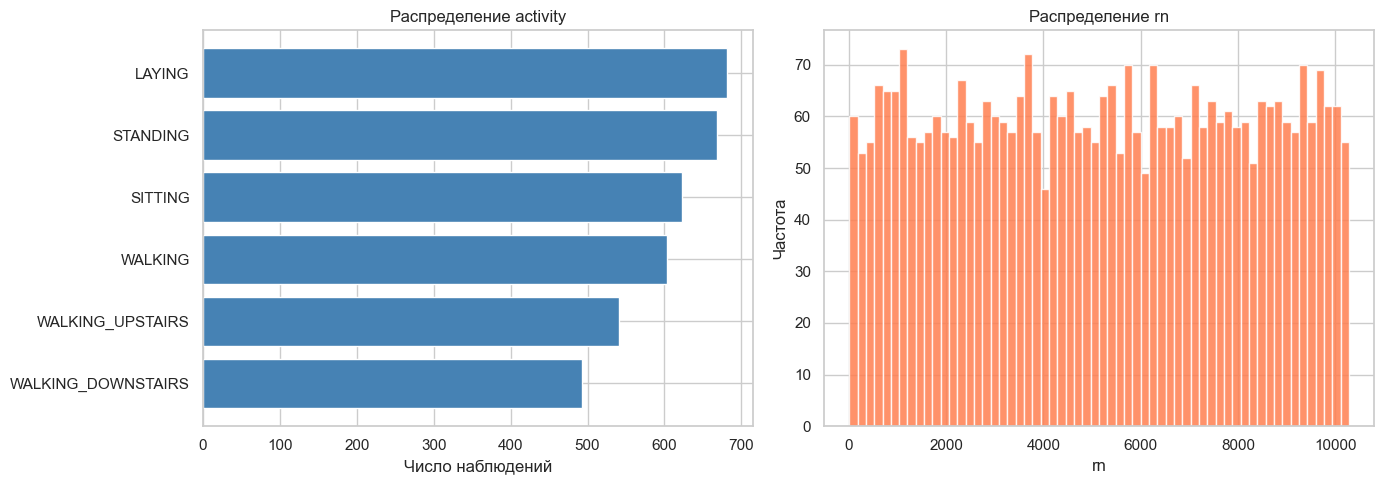

In [1158]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

act_counts = df["activity"].value_counts().sort_values(ascending=True)
axes[0].barh(act_counts.index.astype(str), act_counts.values, color="steelblue")
axes[0].set_title("Распределение activity")
axes[0].set_xlabel("Число наблюдений")

axes[1].hist(df["rn"], bins=60, color="coral", edgecolor="white", alpha=0.85)
axes[1].set_title("Распределение rn")
axes[1].set_xlabel("rn")
axes[1].set_ylabel("Частота")

plt.tight_layout()
plt.show()

In [1159]:
X_raw.describe()

,tBodyAcc.mean.X,tBodyAcc.mean.Y,tBodyAcc.mean.Z,tBodyAcc.std.X,tBodyAcc.std.Y,tBodyAcc.std.Z,tBodyAcc.mad.X,tBodyAcc.mad.Y,tBodyAcc.mad.Z,tBodyAcc.max.X,...,fBodyBodyGyroJerkMag.meanFreq,fBodyBodyGyroJerkMag.skewness,fBodyBodyGyroJerkMag.kurtosis,angle.tBodyAccMean.gravity,angle.tBodyAccJerkMean.gravityMean,angle.tBodyGyroMean.gravityMean,angle.tBodyGyroJerkMean.gravityMean,angle.X.gravityMean,angle.Y.gravityMean,angle.Z.gravityMean
count,3609.000000,3609.000000,3609.000000,3609.000000,3609.000000,3609.000000,3609.000000,3609.000000,3609.000000,3609.000000,...,3609.000000,3609.000000,3609.000000,3609.000000,3609.000000,3609.000000,3609.000000,3609.000000,3609.000000,3609.000000
mean,0.274544,-0.017415,-0.109195,-0.608457,-0.506265,-0.614482,-0.634634,-0.521660,-0.616047,-0.467034,...,0.128804,-0.300815,-0.619400,0.007561,0.009484,0.029185,-0.010632,-0.496977,0.060040,-0.050202
std,0.063589,0.042589,0.056218,0.439157,0.501627,0.399514,0.413194,0.485282,0.394932,0.540188,...,0.240278,0.317963,0.308303,0.332249,0.448971,0.613615,0.490830,0.509336,0.311308,0.263935
min,-0.521000,-1.000000,-0.926000,-1.000000,-0.999000,-1.000000,-1.000000,-0.999000,-1.000000,-1.000000,...,-0.786000,-0.968000,-0.995000,-0.969000,-0.997000,-1.000000,-0.993000,-0.999000,-1.000000,-0.971000
25%,0.262000,-0.025200,-0.122000,-0.992000,-0.976000,-0.979000,-0.993000,-0.976000,-0.978000,-0.936000,...,-0.015800,-0.533000,-0.836000,-0.118000,-0.281000,-0.478000,-0.398000,-0.816000,-0.015600,-0.122000
50%,0.277000,-0.017200,-0.109000,-0.939000,-0.812000,-0.844000,-0.946000,-0.816000,-0.837000,-0.877000,...,0.132000,-0.341000,-0.706000,0.007740,0.009830,0.029600,-0.013400,-0.716000,0.183000,-0.005260
75%,0.287000,-0.011000,-0.098000,-0.254000,-0.051700,-0.283000,-0.306000,-0.084500,-0.288000,-0.018900,...,0.290000,-0.118000,-0.501000,0.142000,0.309000,0.554000,0.374000,-0.522000,0.252000,0.104000
max,0.693000,1.000000,1.000000,1.000000,0.980000,1.000000,1.000000,0.988000,1.000000,1.000000,...,0.871000,0.990000,0.957000,0.981000,0.997000,0.999000,0.996000,0.977000,1.000000,0.998000


In [1160]:
X_raw.dtypes.value_counts()

float64    561
Name: count, dtype: int64

In [1161]:
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

Стандартизация. Приводим признаки к нулевому среднему и единичной дисперсии по каждому столбцу. Для **K-means** и расстояний это важно: без масштабирования признаки с большим разбросом «перетянут» кластеризацию на себя.

### Самостоятельно реализуйте один из алгоритмов кластеризации, например **K-means**.

In [1162]:
import numpy as np
from sklearn.base import BaseEstimator, ClusterMixin
from sklearn.utils.validation import check_array


class CustomKMeans(BaseEstimator, ClusterMixin):
    def __init__(self, n_clusters=8, max_iter=300, random_state=None):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.random_state = random_state

    def _labels_from_centers(self, X, centers):
        n, k = X.shape[0], centers.shape[0]
        dist = np.empty((n, k), dtype=np.float64)
        for j in range(k):
            diff = X - centers[j]
            dist[:, j] = (diff * diff).sum(axis=1)
        return dist, np.argmin(dist, axis=1)

    def fit(self, X, y=None):
        X = check_array(X, dtype=np.float64) # type: ignore
        rng = np.random.RandomState(self.random_state)
        n, k = X.shape[0], self.n_clusters
        start = rng.choice(n, size=k, replace=False)
        centers = X[start].copy()

        for _ in range(self.max_iter):
            _, labels = self._labels_from_centers(X, centers)
            new_centers = centers.copy()
            for j in range(k):
                m = labels == j
                if m.any():
                    new_centers[j] = X[m].mean(axis=0)
                else:
                    new_centers[j] = X[rng.randint(n)]
            if np.allclose(new_centers, centers):
                break
            centers = new_centers

        dist, labels = self._labels_from_centers(X, centers)
        self.cluster_centers_ = centers
        self.labels_ = labels
        self.inertia_ = float(dist[np.arange(n), labels].sum())
        return self

    def predict(self, X):
        if self.cluster_centers_ is None:
            raise RuntimeError("Нужен fit перед predict.")
        X = check_array(X, dtype=np.float64) # type: ignore
        _, labels = self._labels_from_centers(X, self.cluster_centers_)
        return labels

    def fit_predict(self, X, y=None): # type: ignore
        return self.fit(X, y).labels_


### При обучении использовать **подбор гиперпараметров**.

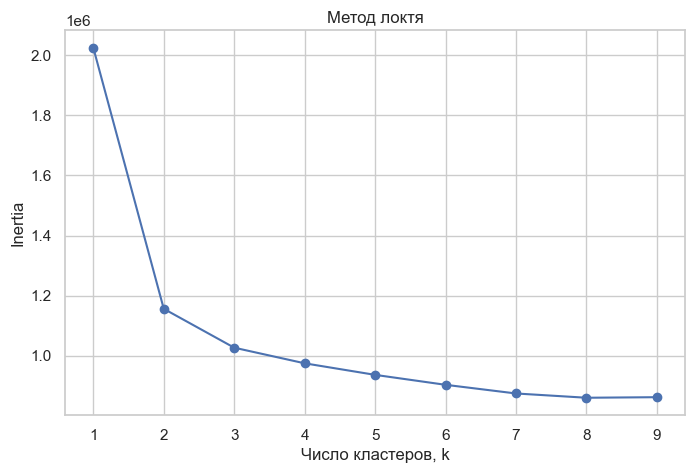

In [1163]:
ks = range(1, 10)
inertias = []

for k in ks:
    model = KMeans(n_clusters=k)
    model.fit(X)
    inertias.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(ks, inertias, "-o")
plt.xlabel("Число кластеров, k")
plt.ylabel("Inertia")
plt.xticks(ks)
plt.title("Метод локтя")
plt.show()


Оптимальное число кластеров по методу локтя: 2

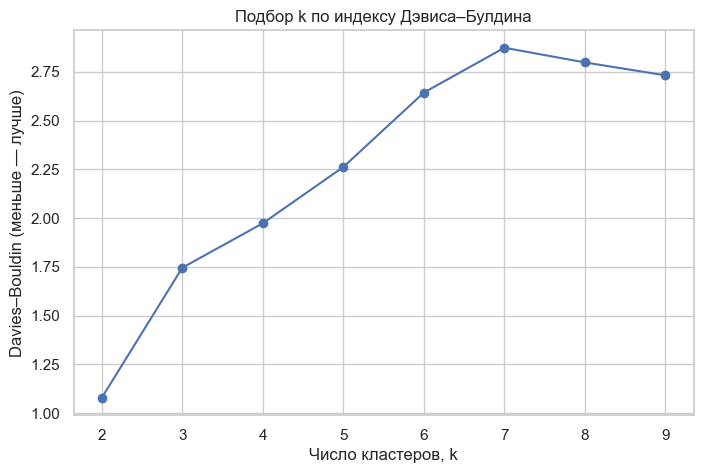

Минимум Davies–Bouldin при k = 2


In [1164]:
ks_db = range(2, 10)
db_scores = []
for k in ks_db:
    km = KMeans(n_clusters=k, random_state=rng, n_init="auto")
    km.fit(X)
    db_scores.append(davies_bouldin_score(X, km.labels_))

plt.figure(figsize=(8, 5))
plt.plot(ks_db, db_scores, "-o")
plt.xlabel("Число кластеров, k")
plt.ylabel("Davies–Bouldin (меньше — лучше)")
plt.xticks(list(ks_db))
plt.title("Подбор k по индексу Дэвиса–Булдина")
plt.show()

best_k_db = list(ks_db)[int(np.argmin(db_scores))]
print("Минимум Davies–Bouldin при k =", best_k_db)

### Также снизить размерность данных с помощью метода главных компонент **PCA** и и понять качество дальнейшей кластеризации всеми использованными реализациями при различном количестве главных компонент.

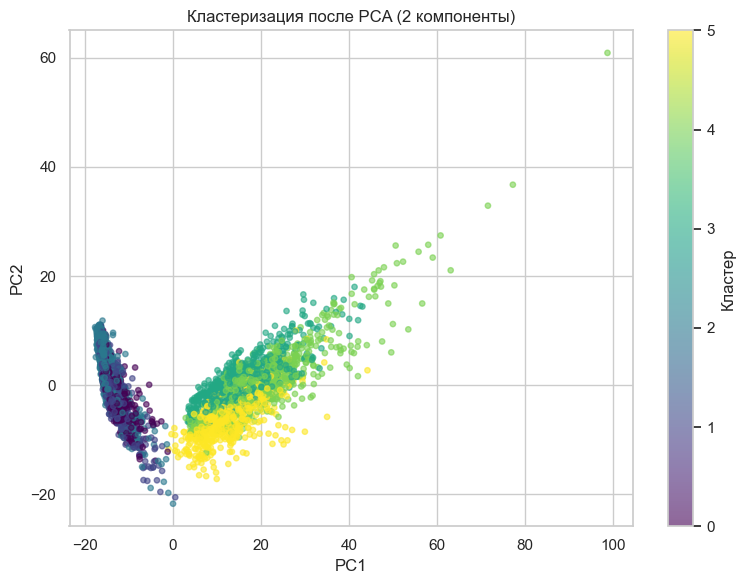

In [1165]:
pca = PCA(n_components=2, random_state=rng)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=Y, cmap="viridis", alpha=0.6, s=15)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Кластеризация после PCA (2 компоненты)")
plt.colorbar(label="Кластер")
plt.tight_layout()
plt.show()

### Визуализировать данные снижением размерности до 2 или 3 с помощью **PCA** и **t-SNE**. В случае проблем с производительностью **t-SNE**, можно сначала до какой то степени снизить размерность с помощью **PCA**, а затем запустить **t-SNE**.

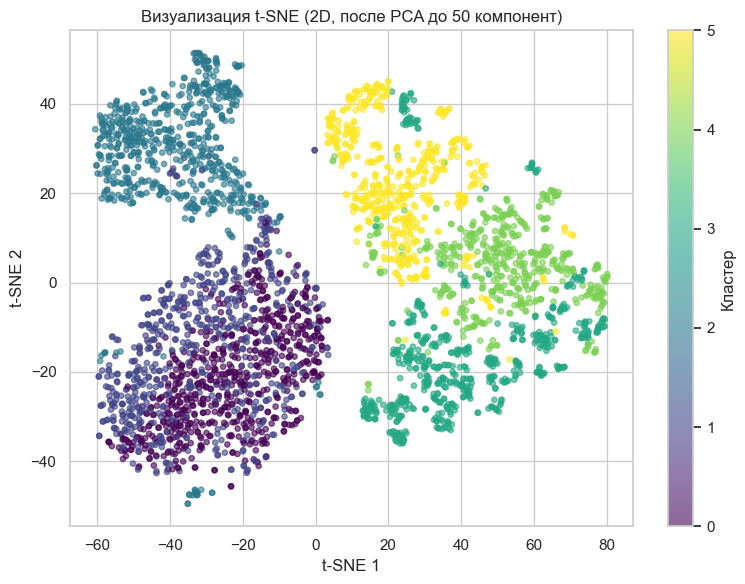

In [1166]:
X_pre = PCA(n_components=50, random_state=rng).fit_transform(X)

tsne = TSNE(
    n_components=2,
    random_state=rng,
    init="pca",
    learning_rate="auto",
)
X_tsne = tsne.fit_transform(X_pre)

plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=Y, cmap="viridis", alpha=0.6, s=15)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("Визуализация t-SNE (2D, после PCA до 50 компонент)")
plt.colorbar(label="Кластер")
plt.tight_layout()
plt.show()

### Обучите модели кластеризации, используя свою реализацию, а также хотя бы две реализации из **sklearn** (**KMeans**, **Affinity Propogation**, **DBSCAN** и тд).

In [1167]:
def clustering_train_metrics(model, X):
    X = np.asarray(X, dtype=float)
    t0 = time.perf_counter()
    labels = np.asarray(model.fit_predict(X))
    train_time = time.perf_counter() - t0

    valid = labels != -1 if -1 in labels else np.ones(len(labels), dtype=bool)
    labs = labels[valid]
    Xv = X[valid]

    out = {
        "train_time_s": float(train_time),
        "silhouette": float("nan"),
        "davies_bouldin": float("nan"),
    }
    
    if labs.size >= 2 and np.unique(labs).size >= 2:
        out["silhouette"] = float(silhouette_score(Xv, labs))
        out["davies_bouldin"] = float(davies_bouldin_score(Xv, labs))

    return out


In [1168]:
models = [
    (KMeans(n_clusters=2, random_state=rng, n_init="auto"), "KMeans"),
    (DBSCAN(eps=10, min_samples=3, n_jobs=-1), "DBSCAN"),
    (CustomKMeans(n_clusters=2, random_state=rng, max_iter=300), "CustomKMeans"),
]

rows = []
for est, name in models:
    row = clustering_train_metrics(est, X)
    row["model"] = name
    row["pca"] = "no pca" # type: ignore
    rows.append(row)

metrics_df = pd.DataFrame(rows)[["model", "train_time_s", "silhouette", "davies_bouldin", "pca"]]
metrics_df


,model,train_time_s,silhouette,davies_bouldin,pca
0,KMeans,0.022649,0.389902,1.078563,no pca
1,DBSCAN,0.052888,-0.006319,1.471005,no pca
2,CustomKMeans,0.036199,0.389902,1.078563,no pca


### Сравнить качество моделей: замерить скорость обучения, вычислить различные метрики качества.

In [1169]:

_LOWER_IS_BETTER = {"train_time_s", "davies_bouldin"}


def plot_metric(df, column):
    plt.figure(figsize=(8, 6))
    sns.barplot(x="model", y=column, hue="pca", data=df)
    plt.title(column)
    plt.ylabel(column)
    plt.show()
    series = df[column]
    if column in _LOWER_IS_BETTER:
        best = series.min()
    else:
        best = series.max()
    winners = df[series == best]
    better = "ниже" if column in _LOWER_IS_BETTER else "выше"
    print(f"{column}: лучшее ({better}) = {best}")
    for _, row in winners.iterrows():
        print(f"  winner: model={row['model']!r}, pca={row['pca']!r}")


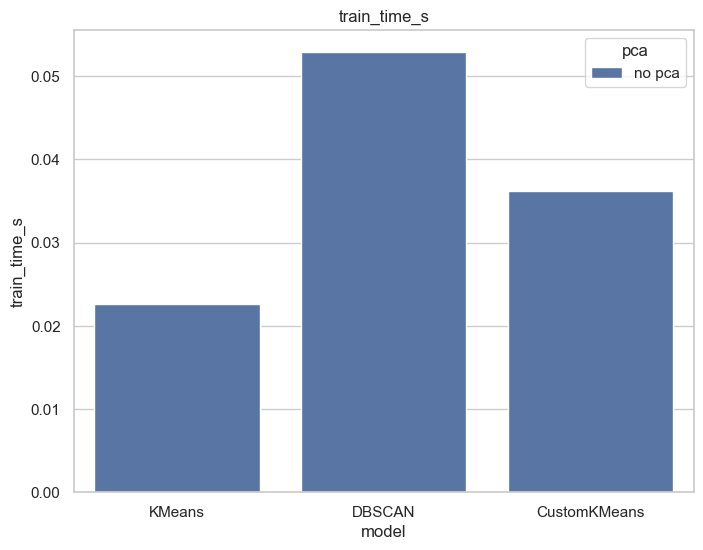

train_time_s: лучшее (ниже) = 0.02264874998945743
  winner: model='KMeans', pca='no pca'


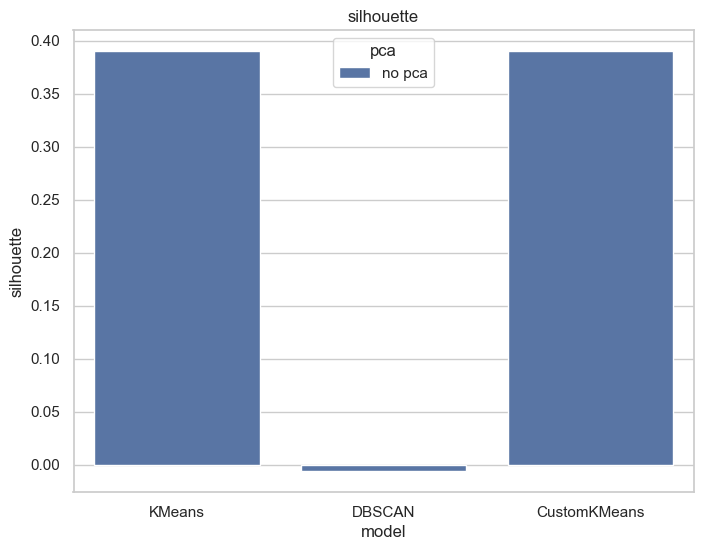

silhouette: лучшее (выше) = 0.38990168994287755
  winner: model='KMeans', pca='no pca'
  winner: model='CustomKMeans', pca='no pca'


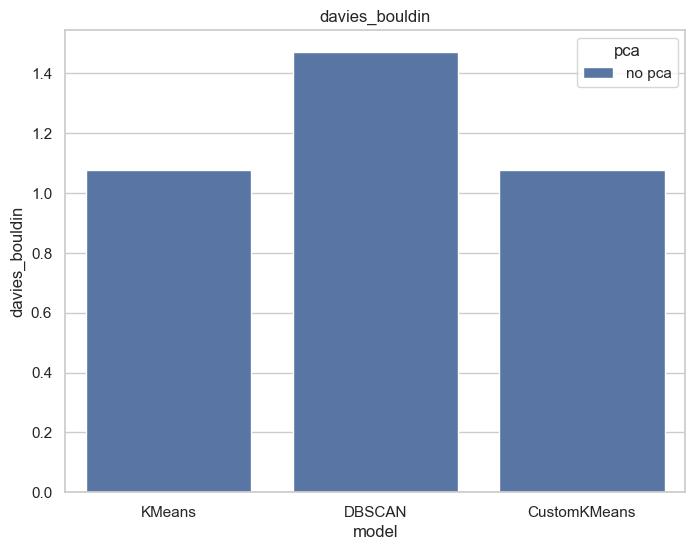

davies_bouldin: лучшее (ниже) = 1.0785629246858464
  winner: model='KMeans', pca='no pca'
  winner: model='CustomKMeans', pca='no pca'


In [1170]:
plot_metric(metrics_df, "train_time_s")
plot_metric(metrics_df, "silhouette")
plot_metric(metrics_df, "davies_bouldin")

In [1171]:
models = [
    (KMeans(n_clusters=2, random_state=rng, n_init="auto"), "KMeans"),
    (DBSCAN(eps=10, min_samples=3, n_jobs=-1), "DBSCAN"),
    (CustomKMeans(n_clusters=2, random_state=rng, max_iter=300), "CustomKMeans"),
]

rows = []
for est, name in models:
    row = clustering_train_metrics(est, X_pca)
    row["model"] = name
    row["pca"] = "pca"  # type: ignore
    rows.append(row)

pca_metrics_df = pd.DataFrame(rows)[
    ["model", "train_time_s", "silhouette", "davies_bouldin", "pca"]
]


all_metrics_df = pd.concat([metrics_df, pca_metrics_df], axis=0, ignore_index=True)
all_metrics_df


,model,train_time_s,silhouette,davies_bouldin,pca
0,KMeans,0.022649,0.389902,1.078563,no pca
1,DBSCAN,0.052888,-0.006319,1.471005,no pca
2,CustomKMeans,0.036199,0.389902,1.078563,no pca
3,KMeans,0.003295,0.694172,0.453164,pca
4,DBSCAN,0.054387,NaN,NaN,pca
5,CustomKMeans,0.001700,0.694172,0.453164,pca


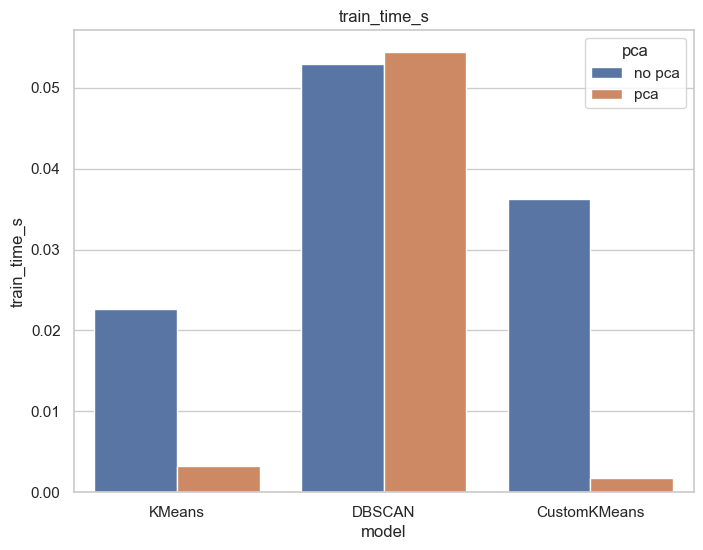

train_time_s: лучшее (ниже) = 0.0017001660307869315
  winner: model='CustomKMeans', pca='pca'


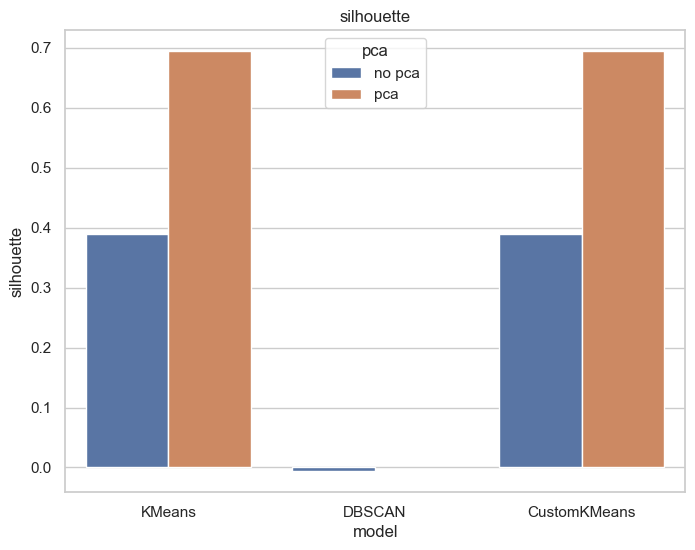

silhouette: лучшее (выше) = 0.6941719474901245
  winner: model='KMeans', pca='pca'
  winner: model='CustomKMeans', pca='pca'


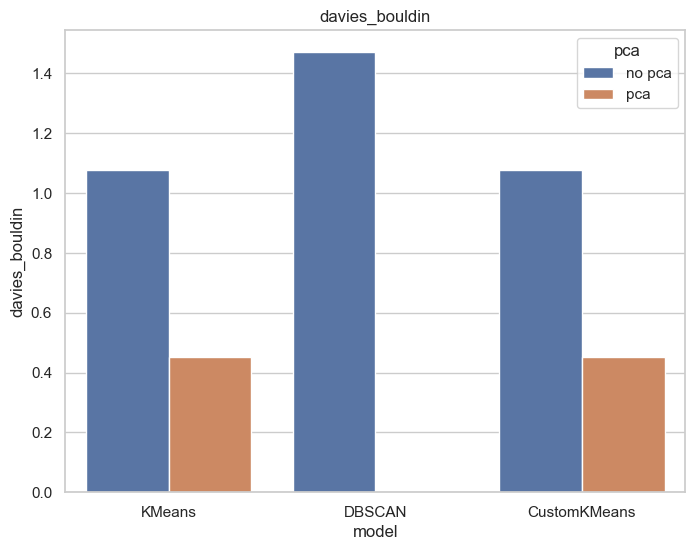

davies_bouldin: лучшее (ниже) = 0.45316402465556443
  winner: model='KMeans', pca='pca'
  winner: model='CustomKMeans', pca='pca'


In [1172]:
plot_metric(all_metrics_df, "train_time_s")
plot_metric(all_metrics_df, "silhouette")
plot_metric(all_metrics_df, "davies_bouldin")


### Итоги

Лучше всего показала себя модель **CustomKMeans** с PCA.